# Exploratory Data Analysis: Mufulira CDF Skills Applicants

## 1. Introduction

This notebook performs exploratory data analysis, data-quality assessment, cleaning, preprocessing, visualization, and validation of the Mufulira Municipal Council CDF Skills Development applicants dataset.

The analysis aims to understand the structure of the applicant records and identify patterns in the available applicant information while preparing a complete and consistent dataset for further analysis.

The objectives are to:

- inspect the structure and contents of the raw dataset;
- identify missing, duplicated, and inconsistent records;
- identify placeholder values such as `Unspecified`;
- apply appropriate cleaning and preprocessing techniques;
- explore the distribution of applicant records;
- verify that the final cleaned dataset contains no null, NaN, or unresolved placeholder values; and
- export the cleaned dataset as a pipe-delimited CSV file.

The raw dataset is preserved separately and is not modified by this notebook.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

input_path = (
    "../db-unza26-csc4792-mufulira_cdf_skills_applicants.csv"
)

output_path = (
    "../cleaned_datasets/"
    "db-unza26-csc4792-mufulira_cdf_skills_applicants.csv"
)

df = pd.read_csv(
    input_path,
    sep="|",
    low_memory=False
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (224, 15)


,Constituency,No,Ward,Name_of_Pupil,NRC,Gender,Date_of_Birth,Type_of_Vulnerability,Study_Programme,Study_Type,Course_Duration,Name_of_Skills_Institution,Total,Guardian_Parent_Name,Source_File
0,Kantanshi,3,NaN,RST eR TRE FRR RATER FSHETOT TES RT ETETSSEE T...,NaN,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Final-Skills-2026-Approved-Applicants-Kantansh...
1,Kantanshi,4,DAVID KAUNDA,SONDASHICHONGO | 340838667 [ | DAVID 23.03.198...,408740/66/1,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Final-Skills-2026-Approved-Applicants-Kantansh...
2,Kantanshi,8,MAINASOKO,eee Oe MWELA J. DONALD [37731466/1 [LEYAMUKUTU...,382625/66/1,F,5/6/2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Final-Skills-2026-Approved-Applicants-Kantansh...
3,Kantanshi,46,NaN,MAINA SOKO BWALYA BRIGHT 7120/2006 [FINANCIAL ...,660860/67/1,F,8/9/2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kantanshi-2025-Approved-Skills-Replacements.pdf
4,Kantanshi,1,NaN,Bwafwano Chikumbi Gerald Male 360 Degree One M...,503995/67/1,NaN,11/4/1995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kantanshi-2025-APPROVED-SKILLS-DEVELOPEMENT.pdf


## 2. Initial Dataset Inspection

The initial inspection examines the dimensions, column names, data types, missing values, duplicate records, and sample records in the raw CDF Skills applicants dataset.

This establishes the data-quality characteristics that will guide the subsequent cleaning and preprocessing decisions.

In [2]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nFirst 10 records:")
display(df.head(10))

Number of rows: 224
Number of columns: 15

Column names:
['Constituency', 'No', 'Ward', 'Name_of_Pupil', 'NRC', 'Gender', 'Date_of_Birth', 'Type_of_Vulnerability', 'Study_Programme', 'Study_Type', 'Course_Duration', 'Name_of_Skills_Institution', 'Total', 'Guardian_Parent_Name', 'Source_File']

Data types:
Constituency                      str
No                              int64
Ward                              str
Name_of_Pupil                     str
NRC                               str
Gender                            str
Date_of_Birth                     str
Type_of_Vulnerability         float64
Study_Programme               float64
Study_Type                    float64
Course_Duration               float64
Name_of_Skills_Institution    float64
Total                         float64
Guardian_Parent_Name          float64
Source_File                       str
dtype: object

Missing values:


Constituency                    0
No                              0
Ward                          218
Name_of_Pupil                   0
NRC                            37
Gender                        180
Date_of_Birth                 149
Type_of_Vulnerability         224
Study_Programme               224
Study_Type                    224
Course_Duration               224
Name_of_Skills_Institution    224
Total                         224
Guardian_Parent_Name          224
Source_File                     0
dtype: int64


Duplicate rows: 0

First 10 records:


,Constituency,No,Ward,Name_of_Pupil,NRC,Gender,Date_of_Birth,Type_of_Vulnerability,Study_Programme,Study_Type,Course_Duration,Name_of_Skills_Institution,Total,Guardian_Parent_Name,Source_File
0,Kantanshi,3,NaN,RST eR TRE FRR RATER FSHETOT TES RT ETETSSEE T...,NaN,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Final-Skills-2026-Approved-Applicants-Kantansh...
1,Kantanshi,4,DAVID KAUNDA,SONDASHICHONGO | 340838667 [ | DAVID 23.03.198...,408740/66/1,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Final-Skills-2026-Approved-Applicants-Kantansh...
2,Kantanshi,8,MAINASOKO,eee Oe MWELA J. DONALD [37731466/1 [LEYAMUKUTU...,382625/66/1,F,5/6/2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Final-Skills-2026-Approved-Applicants-Kantansh...
3,Kantanshi,46,NaN,MAINA SOKO BWALYA BRIGHT 7120/2006 [FINANCIAL ...,660860/67/1,F,8/9/2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kantanshi-2025-Approved-Skills-Replacements.pdf
4,Kantanshi,1,NaN,Bwafwano Chikumbi Gerald Male 360 Degree One M...,503995/67/1,NaN,11/4/1995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kantanshi-2025-APPROVED-SKILLS-DEVELOPEMENT.pdf
5,Kantanshi,2,NaN,Bwafwano Bwalya Peggy Female Articulated Dump ...,382135/66/1,NaN,16/9/2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kantanshi-2025-APPROVED-SKILLS-DEVELOPEMENT.pdf
6,Kantanshi,3,NaN,Bwafwano Chibye Albertina Female Computer stud...,340534/66/1,NaN,10/10/1997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kantanshi-2025-APPROVED-SKILLS-DEVELOPEMENT.pdf
7,Kantanshi,4,NaN,Bwafwano Chisanga Maulumbo Female Computer stu...,404296/66/1,NaN,26/6/2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kantanshi-2025-APPROVED-SKILLS-DEVELOPEMENT.pdf
8,Kantanshi,5,NaN,Bwafwano Kyembe Cindy Female Designing Cutteri...,416979/67/1,NaN,13/5/1996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kantanshi-2025-APPROVED-SKILLS-DEVELOPEMENT.pdf
9,Kantanshi,6,NaN,Bwafwano Katamba Agel Male Drill ring One Mont...,347201/66/1,NaN,22/3/1995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kantanshi-2025-APPROVED-SKILLS-DEVELOPEMENT.pdf


## 3. Identification of Missing and Placeholder Values

Applicant information extracted from PDF documents may contain actual null values, blank strings, or textual placeholders such as `Unspecified`, `N/A`, or `None`.

These values are identified before cleaning so that each applicant field can be handled using an appropriate preprocessing rule.

In [3]:
missing_tokens = [
    "Unspecified",
    "unspecified",
    "N/A",
    "n/a",
    "NA",
    "na",
    "None",
    "none",
    ""
]

print("Missing and placeholder values by column:\n")

for column in df.columns:
    values = df[column].astype("string").str.strip()

    null_count = int(df[column].isna().sum())
    placeholder_count = int(values.isin(missing_tokens).sum())

    if null_count > 0 or placeholder_count > 0:
        print(
            f"{column}: "
            f"{null_count} actual nulls, "
            f"{placeholder_count} placeholder values"
        )

Missing and placeholder values by column:

Ward: 218 actual nulls, 0 placeholder values
NRC: 37 actual nulls, 0 placeholder values
Gender: 180 actual nulls, 0 placeholder values
Date_of_Birth: 149 actual nulls, 0 placeholder values
Type_of_Vulnerability: 224 actual nulls, 0 placeholder values
Study_Programme: 224 actual nulls, 0 placeholder values
Study_Type: 224 actual nulls, 0 placeholder values
Course_Duration: 224 actual nulls, 0 placeholder values
Name_of_Skills_Institution: 224 actual nulls, 0 placeholder values
Total: 224 actual nulls, 0 placeholder values
Guardian_Parent_Name: 224 actual nulls, 0 placeholder values


## 4. Creation of Cleaned Working Dataset

A separate working copy is created so that the original extracted applicant dataset remains unchanged.

Placeholder values are temporarily standardized as missing values so that they can be resolved systematically during preprocessing.

In [4]:
df_cleaned = df.copy()

for column in df_cleaned.columns:
    df_cleaned[column] = (
        df_cleaned[column]
        .astype("string")
        .str.strip()
        .replace(missing_tokens, pd.NA)
    )

print("Cleaned working dataset created.")
display(df_cleaned.head())

Cleaned working dataset created.


,Constituency,No,Ward,Name_of_Pupil,NRC,Gender,Date_of_Birth,Type_of_Vulnerability,Study_Programme,Study_Type,Course_Duration,Name_of_Skills_Institution,Total,Guardian_Parent_Name,Source_File
0,Kantanshi,3,<NA>,RST eR TRE FRR RATER FSHETOT TES RT ETETSSEE T...,<NA>,F,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,Final-Skills-2026-Approved-Applicants-Kantansh...
1,Kantanshi,4,DAVID KAUNDA,SONDASHICHONGO | 340838667 [ | DAVID 23.03.198...,408740/66/1,F,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,Final-Skills-2026-Approved-Applicants-Kantansh...
2,Kantanshi,8,MAINASOKO,eee Oe MWELA J. DONALD [37731466/1 [LEYAMUKUTU...,382625/66/1,F,5/6/2007,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,Final-Skills-2026-Approved-Applicants-Kantansh...
3,Kantanshi,46,<NA>,MAINA SOKO BWALYA BRIGHT 7120/2006 [FINANCIAL ...,660860/67/1,F,8/9/2002,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,Kantanshi-2025-Approved-Skills-Replacements.pdf
4,Kantanshi,1,<NA>,Bwafwano Chikumbi Gerald Male 360 Degree One M...,503995/67/1,<NA>,11/4/1995,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,Kantanshi-2025-APPROVED-SKILLS-DEVELOPEMENT.pdf


## 5. Duplicate Record Handling

Duplicate applicant records may cause the same applicant to be counted more than once. Duplicate rows are therefore identified and removed from the cleaned working dataset.

In [5]:
duplicate_count = int(df_cleaned.duplicated().sum())

print("Duplicate rows identified:", duplicate_count)

df_cleaned = df_cleaned.drop_duplicates().copy()

print("Rows remaining after duplicate removal:", len(df_cleaned))

Duplicate rows identified: 0
Rows remaining after duplicate removal: 224


## 6. Data-Type Assessment

The cleaned dataset is divided into numerical and text or categorical fields.

This distinction is important because numerical applicant attributes and descriptive applicant information require different preprocessing approaches.

In [6]:
numeric_columns = df_cleaned.select_dtypes(
    include=["number"]
).columns.tolist()

text_columns = [
    column
    for column in df_cleaned.columns
    if column not in numeric_columns
]

print("Numerical columns:")
print(numeric_columns)

print("\nText/categorical columns:")
print(text_columns)

Numerical columns:
[]

Text/categorical columns:
['Constituency', 'No', 'Ward', 'Name_of_Pupil', 'NRC', 'Gender', 'Date_of_Birth', 'Type_of_Vulnerability', 'Study_Programme', 'Study_Type', 'Course_Duration', 'Name_of_Skills_Institution', 'Total', 'Guardian_Parent_Name', 'Source_File']


## 7. Applicant Field Inspection

The applicant fields are reviewed to understand the information represented in the dataset and to identify fields that are appropriate for numerical or categorical analysis.

Applicant identifiers and personal-information fields are retained as extracted unless a data-quality issue requires preprocessing.

In [7]:
print("Unique values by field:\n")

for column in df_cleaned.columns:
    unique_count = df_cleaned[column].nunique(dropna=True)
    print(f"{column}: {unique_count} unique values")

Unique values by field:

Constituency: 3 unique values
No: 211 unique values
Ward: 6 unique values
Name_of_Pupil: 224 unique values
NRC: 186 unique values
Gender: 2 unique values
Date_of_Birth: 75 unique values
Type_of_Vulnerability: 0 unique values
Study_Programme: 0 unique values
Study_Type: 0 unique values
Course_Duration: 0 unique values
Name_of_Skills_Institution: 0 unique values
Total: 0 unique values
Guardian_Parent_Name: 0 unique values
Source_File: 6 unique values


## 8. Missing-Value Treatment

Missing values are handled according to the type and meaning of each applicant field.

For numerical fields, the median is used where a valid numerical distribution exists.

For categorical or descriptive fields, the most frequent valid value is used where appropriate. Where no suitable repeated value exists, `Not recorded` is used rather than leaving the field null.

This ensures that the final cleaned dataset contains complete values without inventing unsupported applicant information.

In [8]:
# Numerical fields
for column in numeric_columns:
    if df_cleaned[column].isna().any():
        median_value = df_cleaned[column].median()

        if pd.notna(median_value):
            df_cleaned[column] = df_cleaned[column].fillna(
                median_value
            )

# Text/categorical fields
for column in text_columns:
    if df_cleaned[column].isna().any():
        mode_values = df_cleaned[column].mode(dropna=True)

        if len(mode_values) > 0:
            df_cleaned[column] = df_cleaned[column].fillna(
                mode_values.iloc[0]
            )
        else:
            df_cleaned[column] = df_cleaned[column].fillna(
                "Not recorded"
            )

print("Missing-value treatment completed.")

Missing-value treatment completed.


## 9. Missing-Value Verification

The cleaned applicant dataset is checked to confirm that no null or NaN values remain after preprocessing.

In [9]:
remaining_missing = int(df_cleaned.isna().sum().sum())

print("Total remaining null/NaN values:", remaining_missing)

display(df_cleaned.isna().sum())

Total remaining null/NaN values: 0


Constituency                  0
No                            0
Ward                          0
Name_of_Pupil                 0
NRC                           0
Gender                        0
Date_of_Birth                 0
Type_of_Vulnerability         0
Study_Programme               0
Study_Type                    0
Course_Duration               0
Name_of_Skills_Institution    0
Total                         0
Guardian_Parent_Name          0
Source_File                   0
dtype: int64

## 10. Applicant Distribution

The categorical fields are examined to identify suitable attributes for summarizing the distribution of CDF Skills Development applicants.

Personal identifiers such as applicant names and NRC numbers are not used as analytical variables or displayed in visualizations.

In [10]:
# Identify categorical fields suitable for analysis
candidate_columns = []

for column in text_columns:
    # Do not use personal-identification fields for visualization
    column_name = str(column).lower()

    if any(term in column_name for term in ["name", "nrc", "phone", "guardian"]):
        continue

    counts = df_cleaned[column].value_counts(dropna=True)

    if 2 <= len(counts) <= 15:
        candidate_columns.append((column, counts))

print("Suitable analytical categorical fields:")

for column, counts in candidate_columns:
    print(f"- {column}: {len(counts)} categories")

Suitable analytical categorical fields:
- Constituency: 3 categories
- Ward: 6 categories
- Gender: 2 categories
- Source_File: 6 categories


## 11. Distribution of Applicants

A bar chart is used to compare the number of applicants across a suitable non-identifying categorical field.

This provides a simple view of how the applicants are distributed across the selected category.

Selected field: Constituency


Constituency
Mufulira Central    180
Kantanshi            30
Kankoyo              14
Name: count, dtype: Int64

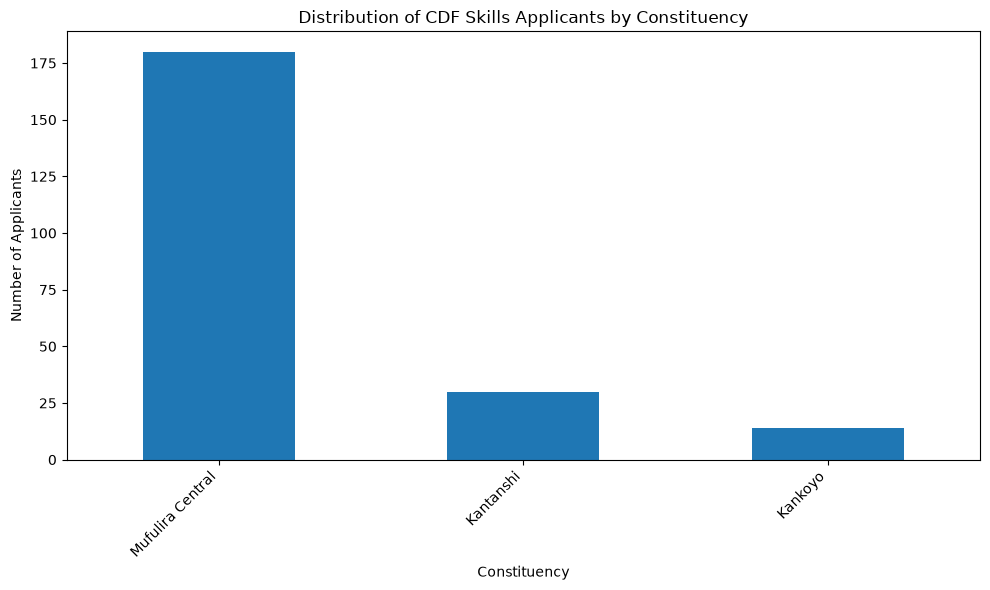

In [11]:
if candidate_columns:
    selected_column, applicant_counts = candidate_columns[0]

    print("Selected field:", selected_column)
    display(applicant_counts)

    plt.figure(figsize=(10, 6))

    applicant_counts.plot(kind="bar")

    plt.title(f"Distribution of CDF Skills Applicants by {selected_column}")
    plt.xlabel(selected_column)
    plt.ylabel("Number of Applicants")
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()
else:
    print("No suitable non-identifying categorical field was found.")

## 12. Numerical Applicant Analysis

Numerical fields are examined to identify useful quantitative applicant attributes.

Identifier fields are excluded from numerical interpretation because numerical-looking identifiers do not represent measurable quantities.

In [12]:
# Identify useful numerical fields while excluding identifiers
useful_numeric_columns = []

for column in numeric_columns:
    column_name = str(column).lower()

    if any(term in column_name for term in ["id", "nrc", "phone"]):
        continue

    if df_cleaned[column].dropna().nunique() > 1:
        useful_numeric_columns.append(column)

print("Useful numerical fields:")
print(useful_numeric_columns)

for column in useful_numeric_columns:
    print(f"\nSummary for {column}:")
    display(df_cleaned[column].describe())

Useful numerical fields:
[]


## 13. Final Data Quality Verification

The final cleaning stage ensures that no null values, NaN values, unresolved placeholder values, or duplicate records remain in the cleaned applicant dataset.

Text fields are also standardized by removing unnecessary leading and trailing whitespace.

In [13]:
# Standardize text fields
for column in df_cleaned.columns:
    if (
        df_cleaned[column].dtype == "object"
        or str(df_cleaned[column].dtype) == "string"
    ):
        df_cleaned[column] = (
            df_cleaned[column]
            .astype("string")
            .str.strip()
        )

final_missing_tokens = [
    "Unspecified",
    "unspecified",
    "N/A",
    "n/a",
    "NA",
    "na",
    "None",
    "none",
    ""
]

# Replace any remaining placeholder values
for column in df_cleaned.columns:
    df_cleaned[column] = df_cleaned[column].replace(
        final_missing_tokens,
        pd.NA
    )

# Resolve any missing values created by the final replacement
for column in df_cleaned.columns:
    if df_cleaned[column].isna().any():
        if column in numeric_columns:
            median_value = df_cleaned[column].median()

            if pd.notna(median_value):
                df_cleaned[column] = df_cleaned[column].fillna(
                    median_value
                )
        else:
            mode_values = df_cleaned[column].mode(dropna=True)

            if len(mode_values) > 0:
                df_cleaned[column] = df_cleaned[column].fillna(
                    mode_values.iloc[0]
                )
            else:
                df_cleaned[column] = df_cleaned[column].fillna(
                    "Not recorded"
                )

print("Final cleaning completed.")

Final cleaning completed.


## 14. Final Verification

The cleaned applicant dataset is checked before export to confirm that it contains no null or NaN values, no duplicate records, and no unresolved placeholder values.

In [14]:
remaining_nulls = int(df_cleaned.isna().sum().sum())
remaining_duplicates = int(df_cleaned.duplicated().sum())

unresolved_placeholders = 0

for column in df_cleaned.columns:
    unresolved_placeholders += int(
        df_cleaned[column]
        .astype("string")
        .str.strip()
        .isin(final_missing_tokens)
        .sum()
    )

print("Remaining null/NaN values:", remaining_nulls)
print("Remaining duplicate rows:", remaining_duplicates)
print("Unresolved placeholder values:", unresolved_placeholders)
print("Final number of rows:", len(df_cleaned))

Remaining null/NaN values: 0
Remaining duplicate rows: 0
Unresolved placeholder values: 0
Final number of rows: 224


## 15. Export of Cleaned Dataset

The validated CDF Skills Development applicants dataset is exported as a pipe-delimited CSV file into the project's cleaned-datasets directory.

The original raw dataset remains unchanged.

In [15]:
output_path = (
    "../cleaned_datasets/"
    "db-unza26-csc4792-mufulira_cdf_skills_applicants.csv"
)

df_cleaned.to_csv(
    output_path,
    sep="|",
    index=False
)

print("Cleaned dataset exported successfully:")
print(output_path)

Cleaned dataset exported successfully:
../cleaned_datasets/db-unza26-csc4792-mufulira_cdf_skills_applicants.csv


## 16. Export Verification

The saved CSV is loaded again to verify that the actual exported dataset satisfies the project's cleaning requirements.

In [16]:
df_verified = pd.read_csv(
    output_path,
    sep="|",
    low_memory=False
)

print("Exported dataset shape:", df_verified.shape)
print("Null/NaN values:", int(df_verified.isna().sum().sum()))
print("Duplicate rows:", int(df_verified.duplicated().sum()))

saved_placeholders = 0

for column in df_verified.columns:
    saved_placeholders += int(
        df_verified[column]
        .astype("string")
        .str.strip()
        .isin(final_missing_tokens)
        .sum()
    )

print("Unresolved placeholder values:", saved_placeholders)

Exported dataset shape: (224, 15)
Null/NaN values: 0
Duplicate rows: 0
Unresolved placeholder values: 0
